In [1]:
from src.data import load_data
from src.data.loaders import (document_loader, image_loader, json_loader, tabular_loader, parquet_loader)

file = load_data.discover_data(r"D:\sample_files")

In [2]:
print(file)

{'tabular': [WindowsPath('D:/sample_files/tabular/people.csv')], 'json': [WindowsPath('D:/sample_files/json/sample1.json')], 'parquet': [WindowsPath('D:/sample_files/parquet/titanic.parquet')], 'document': [WindowsPath('D:/sample_files/document/sample-files.com-formatted-report.docx'), WindowsPath('D:/sample_files/document/sample-local-pdf.pdf'), WindowsPath('D:/sample_files/document/simple.txt')], 'image': [WindowsPath('D:/sample_files/image/CompCars.jpg')], 'unsupported': [WindowsPath('D:/sample_files/tabular/file_example_XLS_10.xls')]}


In [3]:
document_one = file['document'][0]

In [4]:
print(document_one)

D:\sample_files\document\sample-files.com-formatted-report.docx


In [5]:
document_text = document_loader.load_document(document_one)

In [6]:
print(document_text[:500])

Quarterly Business Performance Analysis
Q3 2024 Executive Summary
Prepared by: Business Analytics Team
Date: October 15, 2024
Table of Contents
Executive Summary
The third quarter of 2024 demonstrated robust growth across key performance indicators, with notable improvements in market share and operational efficiency. This report provides a detailed analysis of our performance and strategic positioning.
Key Highlights
Revenue growth of 15.2% year-over-year
Operating margin improvement of 2.3 per


In [7]:
tabular_one = file['tabular'][0]

In [8]:
print(tabular_one)

D:\sample_files\tabular\people.csv


In [9]:
tabular_extract = tabular_loader.load_tabular(tabular_one)

In [10]:
print(tabular_extract)

          Index          User Id First Name   Last Name     Sex  \
0             1  fa9F5A381cDc1fF      Wayne    Woodward  Female   
1             2  62Bb7558b45463E      Chase     Salazar  Female   
2             3  427EE16cB352E2b     George      Madden  Female   
3             4  C9F70C0AD3B4dfc     Krista  Stephenson  Female   
4             5  3c1dCb9ffABFED9    Zachary   Robertson  Female   
...         ...              ...        ...         ...     ...   
999995   999996  9CeB9dDeE089DbD     Hayden      Bowman    Male   
999996   999997  24c9Fe5d000cD7F      Sally       Morse  Female   
999997   999998  A5efbFdbaEB6DE8       Brad       Downs    Male   
999998   999999  b2Caab5b2ADcFef     Tamara     Bernard  Female   
999999  1000000  1c95CBC6dBA1d20      Tammy       Curry  Female   

                               Email                   Phone Date of birth  \
0              melodyfox@example.net  001-989-148-4463x52669    1935-11-18   
1           ernestjoseph@example.net   

In [11]:
image_one = file['image'][0]

In [12]:
print(image_one)

D:\sample_files\image\CompCars.jpg


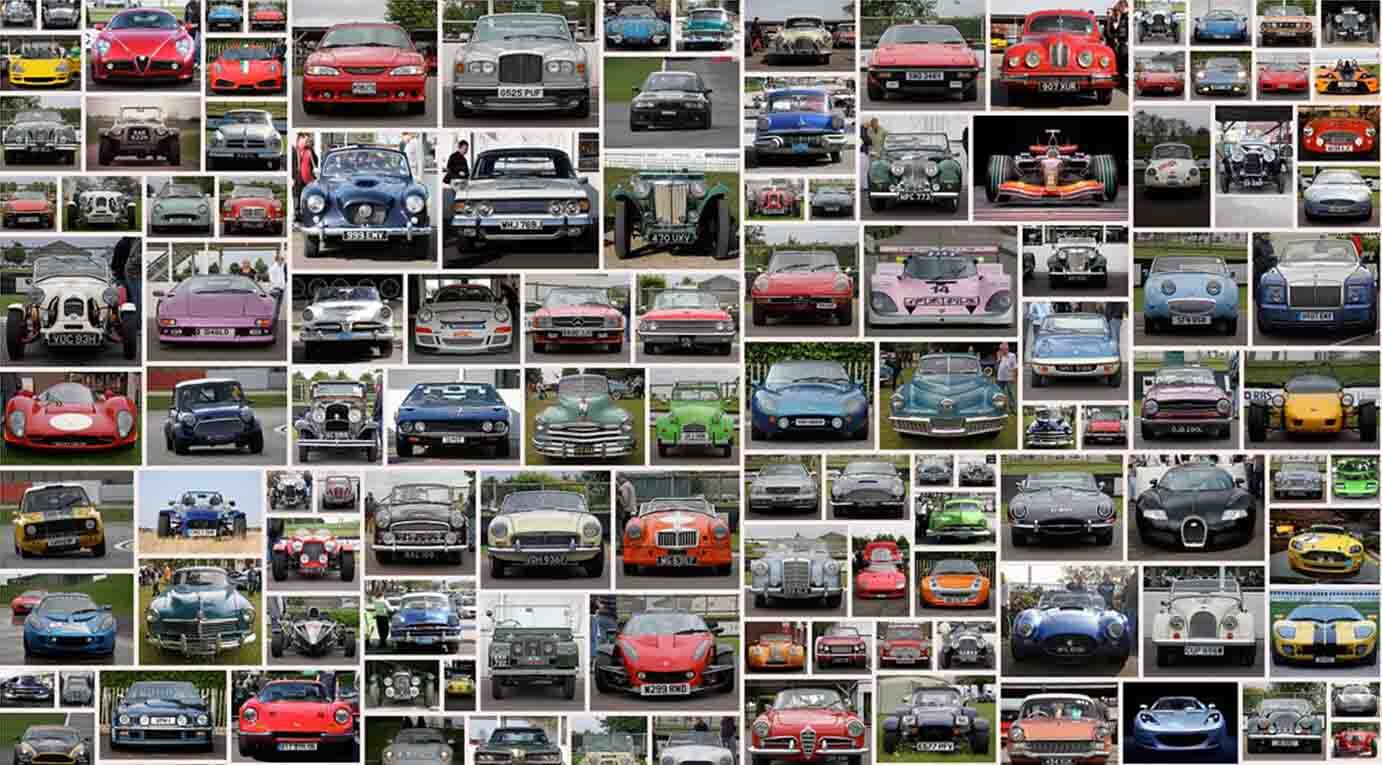

In [13]:
image_path = file["image"][0]

image = image_loader.load_image(image_path)

display(image)

In [14]:
json_one = file['json'][0]
json_extract = json_loader.load_json(json_one)
print(json_extract)

{'fruit': 'Apple', 'size': 'Large', 'color': 'Red'}


In [15]:
parquet_one = file['parquet'][0]
parquet_extract = parquet_loader.load_parquet(parquet_one)
print(parquet_extract)

Parquet loaded successfully using PyArrow: titanic.parquet
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..        

In [16]:
import pyarrow
import pandas as pd

print("PyArrow:", pyarrow.__version__)
print("Pandas:", pd.__version__)
print("File:", parquet_one)

PyArrow: 25.0.1
Pandas: 3.0.6
File: D:\sample_files\parquet\titanic.parquet


In [17]:
import pyarrow.parquet as pq

metadata = pq.read_metadata(parquet_one)

print(metadata)

  created_by: DuckDB
  num_columns: 12
  num_rows: 891
  num_row_groups: 1
  format_version: 1.0
  serialized_size: 1162


In [18]:
parquet_one = file["parquet"][0]

parquet_extract = parquet_loader.load_parquet(parquet_one)

parquet_extract.head()

Parquet loaded successfully using PyArrow: titanic.parquet


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
from src.data import load_data

medquand_file_path = load_data.discover_data(r"D:\archive")

print(medquand_file_path)

{'tabular': [WindowsPath('D:/archive/medquad.csv')], 'json': [], 'parquet': [], 'document': [], 'image': [], 'unsupported': []}


In [20]:
from src.data.loaders import tabular_loader

# We currently have only one tabular dataset,
# so select the first discovered tabular file.
medquad_df = tabular_loader.load_tabular(
    medquand_file_path["tabular"][0]
)

# Preview the first five rows.
medquad_df.head()

,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


In [21]:
from src.data import preprocessing
from src.data.preprocessing import preprocess_data

medquad_clean_df, preprocessing_report = preprocess_data(
    medquad_df
)

preprocessing_report

{'original_rows': 16412,
 'final_rows': 16364,
 'rows_removed': 48,
 'original_columns': 4,
 'final_columns': 4,
 'empty_rows_found': 0,
 'duplicate_rows_found': 48,
 'text_columns_cleaned': ['question', 'answer', 'source', 'focus_area'],
 'remaining_missing_values': 19}

**The 48 duplicates were removed correctly. But I wouldn't automatically remove the remaining 19 missing values yet. We first need to know which columns contain them.**

In [22]:
# Missing values by column
medquad_clean_df.isnull().sum()

question       0
answer         5
source         0
focus_area    14
dtype: int64